# Brain Tumor Dectetion
In this assignement we are going to create a model that detects brain tumors, evealuate to see how it is performing

We are going to train two models
1. CNN mODEL
2. Pre-trained Model

## Part 0: Import packages

In [ ]:
import os
import kagglehub
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shutil
import seaborn as sns
import random

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Import tensorflow related packages
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Densenet
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import densenet


## Connect with Google drive

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/models/"
os.makedirs(drive_path, exist_ok=True)

Mounted at /content/drive


## Part 1: Load Data

In [ ]:
# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brian-tumor-dataset' dataset.
Path to dataset files: /kaggle/input/brian-tumor-dataset


In [ ]:
os.listdir(path)

['metadata_rgb_only.csv', 'Brain Tumor Data Set', 'metadata.csv']

In [ ]:
# Base folder
dataset_folder = os.path.join(path, "Brain Tumor Data Set/Brain Tumor Data Set")

# Check contents
print(os.listdir(dataset_folder))

['Brain Tumor', 'Healthy']


In [ ]:
tumor_folder = os.path.join(dataset_folder, 'Brain Tumor')
normal_folder = os.path.join(dataset_folder, 'Healthy')

# List a few images
print("Tumor images:", os.listdir(tumor_folder)[:5])
print("Normal images:", os.listdir(normal_folder)[:5])

Tumor images: ['Cancer (489).jpg', 'Cancer (72).tif', 'Cancer (2411).jpg', 'Cancer (1065).jpg', 'Cancer (1014).jpg']
Normal images: ['Not Cancer  (446).jpg', 'Not Cancer  (1646).jpg', 'Not Cancer  (1548).jpg', 'Not Cancer  (1864).jpg', 'Not Cancer  (1736).jpg']


### Data Analysis

In [ ]:
# Check the image sizes
import glob, random
from PIL import Image

# Correct usage
files = glob.glob(os.path.join(dataset_folder, '*/*'))
print("Number of files found:", len(files))

# Make sure population >= 20
sample_size = min(20, len(files))
sample = random.sample(files, sample_size)

# Check image sizes
sizes = set()
for f in sample:
    with Image.open(f) as img:
        sizes.add(img.size)

print(sizes)

Number of files found: 4600
{(200, 252), (512, 512), (504, 630), (264, 336), (911, 938), (630, 630), (210, 264), (272, 331), (175, 167), (374, 456), (626, 575), (236, 231), (428, 417), (150, 198), (550, 664), (197, 256)}


In [ ]:
# Check image type
from PIL import Image
import glob
import random

files = glob.glob(os.path.join(dataset_folder, '*/*'))

print("Number of files found:", len(files))
sample = random.sample(files, 20)

modes = set()
for f in sample:
    with Image.open(f) as img:
        modes.add(img.mode)

modes



Number of files found: 4600


{'RGB'}

## Visualizations for whole dataset

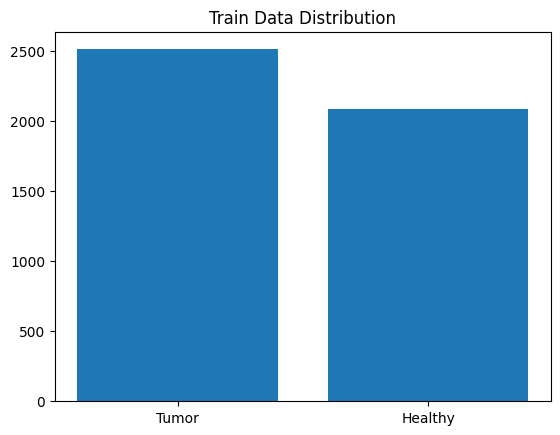

Tumor: 54.63%, Normal: 45.37%


In [ ]:
# Class Distribution for the whole dataset
num_tumor = len(os.listdir(tumor_folder))
num_normal = len(os.listdir(normal_folder))

values = [num_tumor, num_normal]
labels = ["Tumor", "Healthy"]

plt.bar(labels, values)
plt.title("Train Data Distribution")
plt.show()

# Optional: check ratio
total = num_tumor + num_normal
print(f"Tumor: {num_tumor/total:.2%}, Normal: {num_normal/total:.2%}")

Class distribution for the entire dataset

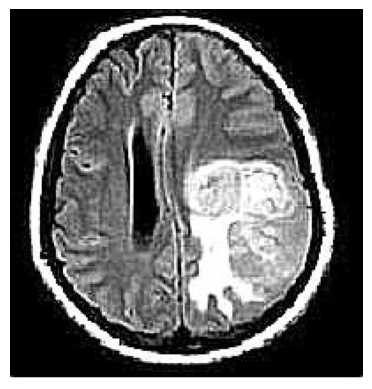

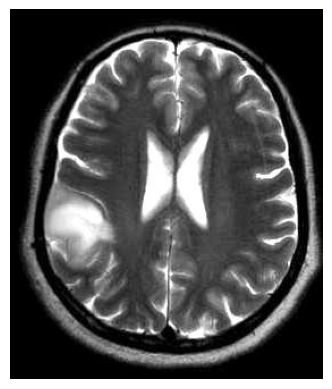

In [ ]:
# Load One tumor and one healthy image
tumor_img_path = os.path.join(tumor_folder, os.listdir(tumor_folder)[3])
healty_img_path = os.path.join(normal_folder, os.listdir(normal_folder)[3])

img = Image.open(tumor_img_path)
img2 = Image.open(healty_img_path)
plt.imshow(img)
plt.axis('off')
plt.show()
plt.imshow(img2)
plt.axis('off')
plt.show()

Load sample images for both healthy and sick

# Part 2: EDA

In [ ]:
# -----------------------------
# Paths
# -----------------------------
# future_train_folder =  os.path.join(dataset_folder, 'future_train')
future_train_folder = 'future_train'
train_folder = 'training'
train_folder = 'train'
test_folder ='test'

# Make directories
for folder in [future_train_folder, train_folder, test_folder]:
    os.makedirs(folder, exist_ok=True)

# -----------------------------
# Prepare file paths and labels
# -----------------------------
tumor_files = [os.path.join(dataset_folder, 'Brain Tumor', f) for f in os.listdir(os.path.join(dataset_folder, 'Brain Tumor'))]
normal_files = [os.path.join(dataset_folder, 'Healthy', f) for f in os.listdir(os.path.join(dataset_folder, 'Healthy'))]

files = tumor_files + normal_files
labels = [1]*len(tumor_files) + [0]*len(normal_files)

# -----------------------------
# Step 1: 90%-10% split for future train
# -----------------------------
files_remaining, files_future, labels_remaining, labels_future = train_test_split(
    files, labels, test_size=0.10, random_state=42, stratify=labels
)

# Move future train images
for f, l in zip(files_future, labels_future):
    class_folder = 'Brain Tumor' if l==1 else 'Healthy'
    dest_folder = os.path.join(future_train_folder, class_folder)
    os.makedirs(dest_folder, exist_ok=True)
    shutil.copy(f, dest_folder)

# -----------------------------
# Step 2: Save 90% into training folder
# -----------------------------
for f, l in zip(files_remaining, labels_remaining):
    class_folder = 'Brain Tumor' if l == 1 else 'Healthy'
    dest_folder = os.path.join(train_folder, class_folder)
    os.makedirs(dest_folder, exist_ok=True)
    shutil.copy(f, dest_folder)

In [ ]:
# -----------------------------
# Step 2: 80%-20% train-test split from remaining 90%
# -----------------------------
files_train, files_test, labels_train, labels_test = train_test_split(
    files_remaining, labels_remaining, test_size=0.20, random_state=42, stratify=labels_remaining
)

# Move train images
for f, l in zip(files_train, labels_train):
    class_folder = 'Brain Tumor' if l==1 else 'Healthy'
    dest_folder = os.path.join(train_folder, class_folder)
    os.makedirs(dest_folder, exist_ok=True)
    shutil.copy(f, dest_folder)

# Move test images
for f, l in zip(files_test, labels_test):
    class_folder = 'Brain Tumor' if l==1 else 'Healthy'
    dest_folder = os.path.join(test_folder, class_folder)
    os.makedirs(dest_folder, exist_ok=True)
    shutil.copy(f, dest_folder)


## Visualizations for train and test

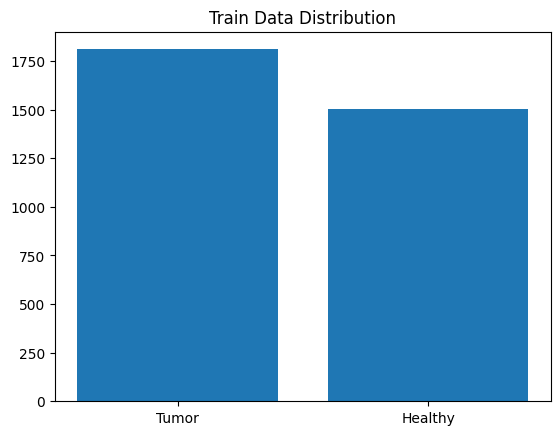

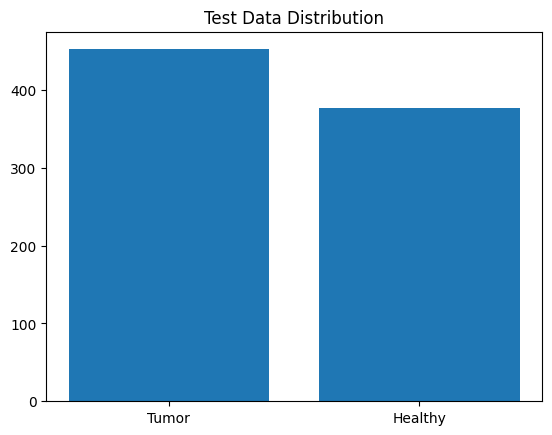

In [ ]:
# Class distributions for training and testing
def count_images(folder):
    tumor = len(os.listdir(os.path.join(folder, "Brain Tumor")))
    healthy = len(os.listdir(os.path.join(folder, "Healthy")))
    return tumor, healthy

train_counts = count_images(train_folder)
test_counts = count_images(test_folder)

labels = ["Tumor", "Healthy"]

plt.bar(labels, train_counts)
plt.title("Train Data Distribution")
plt.show()

plt.bar(labels, test_counts)
plt.title("Test Data Distribution")
plt.show()

Class distribution for both the training and testing models, we can see that the classes are inbalanced but not that much, we can still work with this

### CNN:
### Experiment 1 — No Augmentation

In [ ]:
# Create datagen for training and testing
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


datagen_cnn = ImageDataGenerator(
    rescale=1./255,
)

train_generator_cnn = datagen_cnn.flow_from_directory(
    train_folder,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
)

val_generator_cnn = datagen_cnn.flow_from_directory(
    test_folder,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,

)


Found 3312 images belonging to 2 classes.
Found 828 images belonging to 2 classes.


### CNN — Augmentation on 20% of images

In [ ]:
train_datagen_cnn_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7,1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator_cnn_aug = train_datagen_cnn_aug.flow_from_directory(
    train_folder,  # train_dir now contains original + augmented images
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 3312 images belonging to 2 classes.


### DenseNet
### Experiment 1 — No Augmentation

In [ ]:
# Create datagen for training and testin
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


datagen_dens = ImageDataGenerator(
    preprocessing_function=densenet.preprocess_input,
    rescale=1./255,
)

train_generator_dens = datagen_dens.flow_from_directory(
    train_folder,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
)

val_generator_dens = datagen_dens.flow_from_directory(
    test_folder,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,

)


Found 3312 images belonging to 2 classes.
Found 828 images belonging to 2 classes.


### DenseNet — Augmentation on 20% of images

In [ ]:
train_datagen_dens_aug = ImageDataGenerator(
    preprocessing_function=densenet.preprocess_input,
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7,1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator_dens_aug = train_datagen_dens_aug.flow_from_directory(
    train_folder,  # train_dir now contains original + augmented images
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 3312 images belonging to 2 classes.


## Visualisations for augmentation

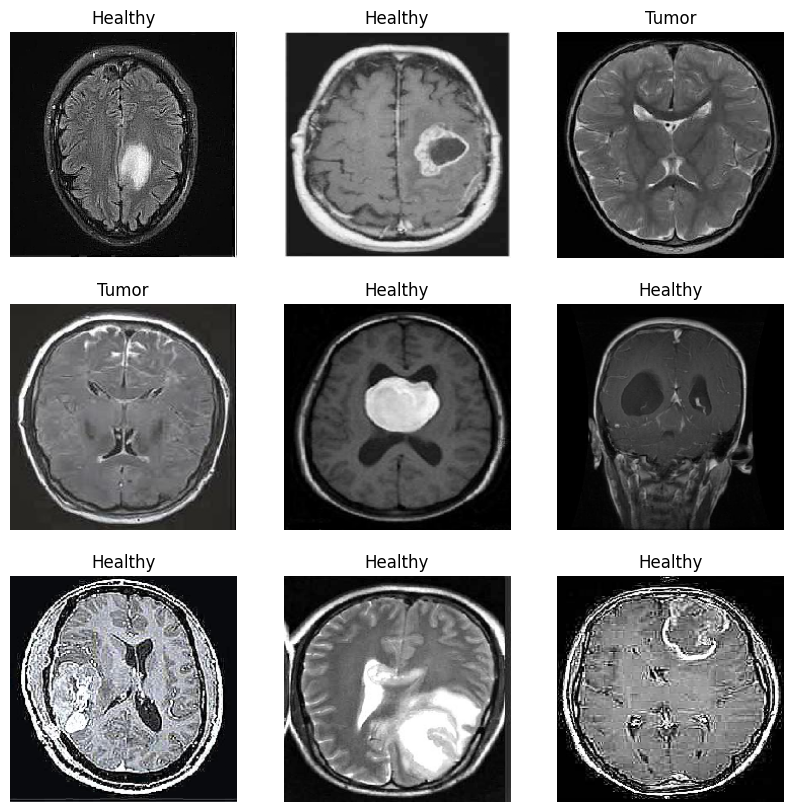

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator_cnn)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Tumor" if labels[i]==1 else "Healthy")
    plt.axis("off")

plt.show()

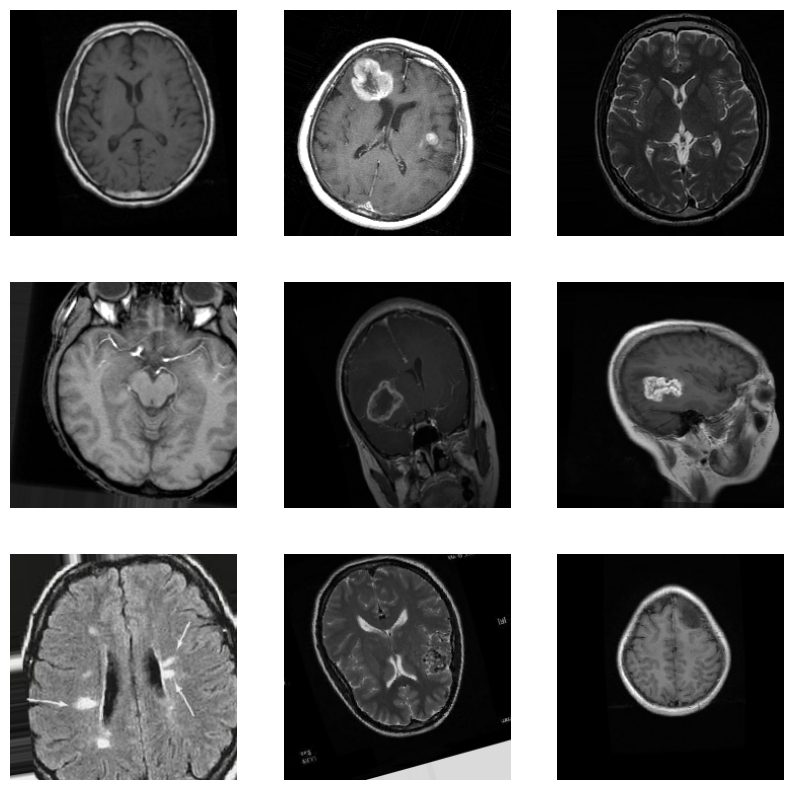

In [ ]:
# Run this after running data augmentation in EDA
images_aug, _ = next(train_generator_cnn_aug)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images_aug[i])
    plt.axis("off")
plt.show()

Summary: From these images, you can see they are zoomed in, some are rotated, etc.

## PART 2: Train Models

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)


In [ ]:
# Save best models on each epoch
checkpoint_cnn = ModelCheckpoint(
    "models/cnn_baseline_best.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


checkpoint_dens = ModelCheckpoint(
    "models/model_v1.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

checkpoint_cnn_aug = ModelCheckpoint(
    "models/cnn_aug_best.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


checkpoint_dens_aug = ModelCheckpoint(
    "models/model_v2.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
def create_cnn_model(input_shape=(224,224,3)):
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=input_shape, padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),

        # Flatten(),
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # binary classification
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Densenet
def create_densenet_model(input_shape=(224,224,3), unfreeze_ratio=0.3):

    # -------------------------
    # Load DenseNet Base
    # -------------------------
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # -------------------------
    # Freeze Layers
    # -------------------------
    total_layers = len(base_model.layers)
    unfreeze_from = int(total_layers * (1 - unfreeze_ratio))

    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False

    for layer in base_model.layers[unfreeze_from:]:
        layer.trainable = True

    # -------------------------
    # Custom Classification Head
    # -------------------------
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # -------------------------
    # Compile Model
    # -------------------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # slightly lower LR works better
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## Run the Experiments

In [ ]:
epochs = 10  # increase for better accuracy


In [ ]:
# CNN: No augmentation applied

cnn_model = create_cnn_model()
history_cnn = cnn_model.fit(
    train_generator_cnn,  # no augmentation for first experiment
    validation_data=val_generator_cnn,
    epochs=epochs,
    # callbacks=[checkpoint_cnn]
)


In [ ]:
# CNN: augmentation applied

cnn_model_aug = create_cnn_model()
history_cnn = cnn_model_aug.fit(
    train_generator_cnn_aug,
    validation_data=val_generator_cnn,
    epochs=epochs,
    callbacks=[checkpoint_cnn_aug]
)


Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.5570 - loss: 0.6967
Epoch 1: val_loss improved from None to 0.69544, saving model to models/cnn_aug_best.h5



Epoch 1: finished saving model to models/cnn_aug_best.h5
104/104 ━━━━━━━━━━━━━━━━━━━━ 66s 555ms/step - accuracy: 0.5806 - loss: 0.6857 - val_accuracy: 0.5459 - val_loss: 0.6954
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6381 - loss: 0.6416
Epoch 2: val_loss did not improve from 0.69544
104/104 ━━━━━━━━━━━━━━━━━━━━ 51s 494ms/step - accuracy: 0.6528 - loss: 0.6251 - val_accuracy: 0.5459 - val_loss: 0.7830
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.6939 - loss: 0.5970
Epoch 3: val_loss did not improve from 0.69544
104/104 ━━━━━━━━━━━━━━━━━━━━ 51s 490ms/step - accuracy: 0.6990 - loss: 0.5863 - val_accuracy: 0.5459 - val_loss: 1.0015
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.6994 - loss: 0.5846
Epoch 4: val_loss did not improve from 0.69544
104/104 ━━━━━━━━━━━━━━━━━━━━ 51s 488ms/step - accuracy: 0.7165 - loss: 0.5699 - val_accuracy: 0.5459 - val_loss: 1.3756
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - a

### Dense Net

In [ ]:
# DenseNet: No augmentation applied
densenet_model = create_densenet_model()
history_densenet = densenet_model.fit(
    train_generator_dens,
    validation_data=val_generator_dens,
    epochs=epochs,
    callbacks=[checkpoint_dens]
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.6995 - loss: 0.5652
Epoch 1: val_loss improved from None to 0.56862, saving model to models/densenet_best.keras

Epoch 1: finished saving model to models/densenet_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 132s 681ms/step - accuracy: 0.7461 - loss: 0.4925 - val_accuracy: 0.8092 - val_loss: 0.5686
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8629 - loss: 0.3145
Epoch 2: val_loss improved from 0.56862 to 0.36629, saving model to models/densenet_best.keras

Epoch 2: finished saving model to models/densenet_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.8735 - loss: 0.2925 - val_accuracy: 0.8527 - val_loss: 0.3663
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9255 - loss: 0.2039
Epoch 3: val_loss improved from 0.36629 to 0.22610, saving model to models/densenet_best.keras

Epoch 3: finished saving model to models/densenet_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# DenseNet: augmentation applied
densenet_model_aug = create_densenet_model()
history_densenet_aug = densenet_model_aug.fit(
    train_generator_dens_aug,
    validation_data=val_generator_dens,
    epochs=epochs,
    callbacks=[checkpoint_dens_aug]
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.6108 - loss: 0.7053
Epoch 1: val_loss improved from None to 0.59588, saving model to models/densenet_aug_best.keras

Epoch 1: finished saving model to models/densenet_aug_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.6549 - loss: 0.6522 - val_accuracy: 0.7536 - val_loss: 0.5959
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.7366 - loss: 0.5461
Epoch 2: val_loss improved from 0.59588 to 0.46091, saving model to models/densenet_aug_best.keras

Epoch 2: finished saving model to models/densenet_aug_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 57s 547ms/step - accuracy: 0.7316 - loss: 0.5438 - val_accuracy: 0.8092 - val_loss: 0.4609
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.7564 - loss: 0.4869
Epoch 3: val_loss improved from 0.46091 to 0.38067, saving model to models/densenet_aug_best.keras

Epoch 3: finished saving model to models/densenet_aug_best.keras
104/10

## PART 3: Evaluate Models

In [ ]:
# -----------------------------
# Helper Function 1: Compute Metrics
# -----------------------------
def compute_metrics(model, generator):
    """
    Compute accuracy, precision, recall, f1-score for a model on a generator.

    Args:
        model : Trained Keras model
        generator : Keras ImageDataGenerator (test/validation set)

    Returns:
        metrics_dict : dictionary with 'accuracy', 'precision', 'recall', 'f1_score'
        y_true, y_pred : arrays for further use (e.g., confusion matrix)
    """
    generator.reset()  # ensure generator starts from beginning
    y_pred_prob = model.predict(generator, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = generator.classes

    metrics_dict = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred)
    }
    return metrics_dict, y_true, y_pred


# -----------------------------
# Helper Function 2: Confusion Matrix
# -----------------------------
def plot_confusion_matrix(y_true, y_pred, class_names=['Normal','Tumor'], figsize=(6,6), cmap='Blues'):
    """
    Plot a confusion matrix using seaborn heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()



# -----------------------------
# Helper Function 3: Training History Plot
# -----------------------------
def plot_training_history(history, model_name='Model'):
    """
    Plot training and validation accuracy & loss curves.
    """
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

{'accuracy': 0.9794685990338164, 'precision': 0.9786666666666667, 'recall': 0.976063829787234, 'f1_score': 0.9773635153129161}


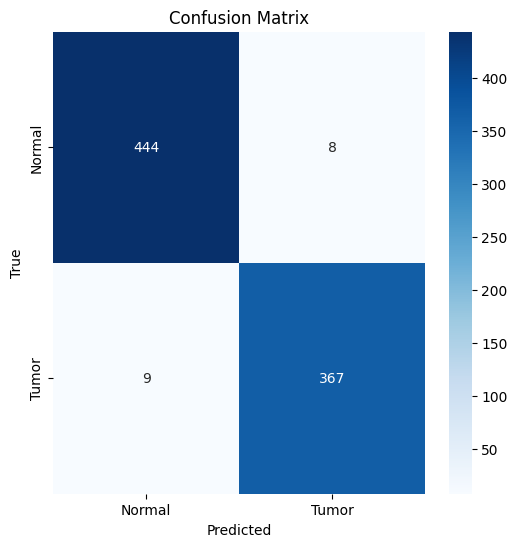

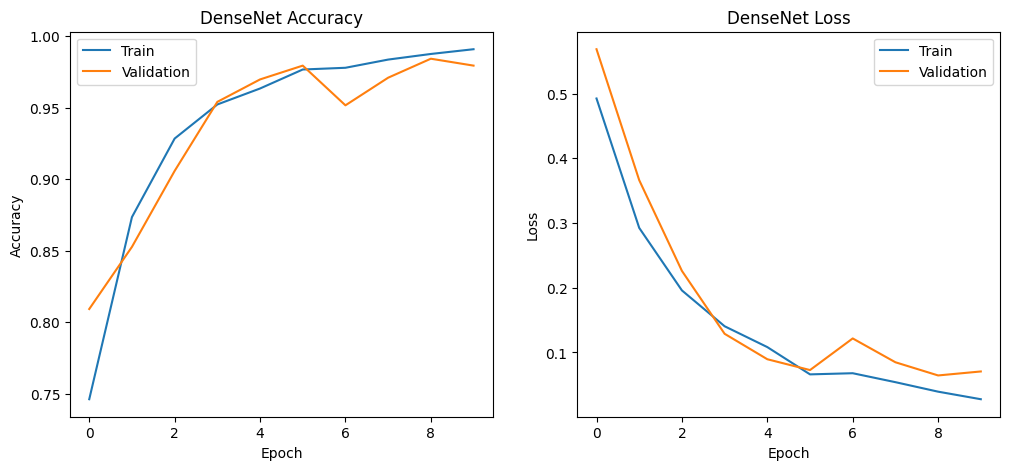

In [ ]:
# Example for Pre-trained model
metrics, y_true, y_pred = compute_metrics(densenet_model, val_generator_dens)
print(metrics)
plot_confusion_matrix(y_true, y_pred)
plot_training_history(history_densenet, 'DenseNet')

In [ ]:
# Example for CNN_aug
metrics, y_true, y_pred = compute_metrics(cnn_model_aug, val_generator_cnn)
print(metrics)  # {'accuracy': ..., 'precision': ..., 'recall': ..., 'f1_score': ...}
plot_confusion_matrix(y_true, y_pred)
plot_training_history(history_cnn_aug, 'CNN Model Aug')


{'accuracy': 0.45410628019323673, 'precision': 0.45410628019323673, 'recall': 1.0, 'f1_score': 0.6245847176079734}


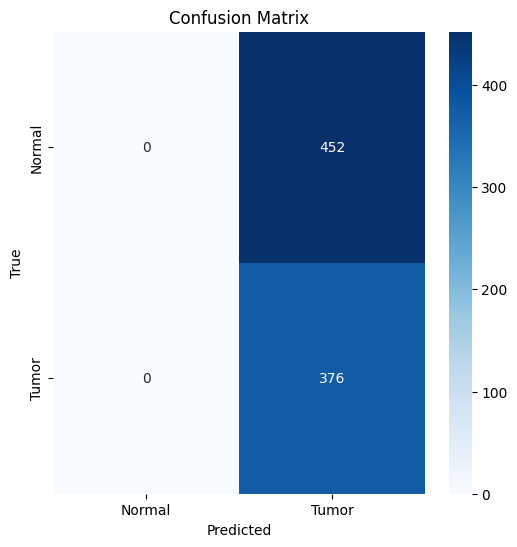

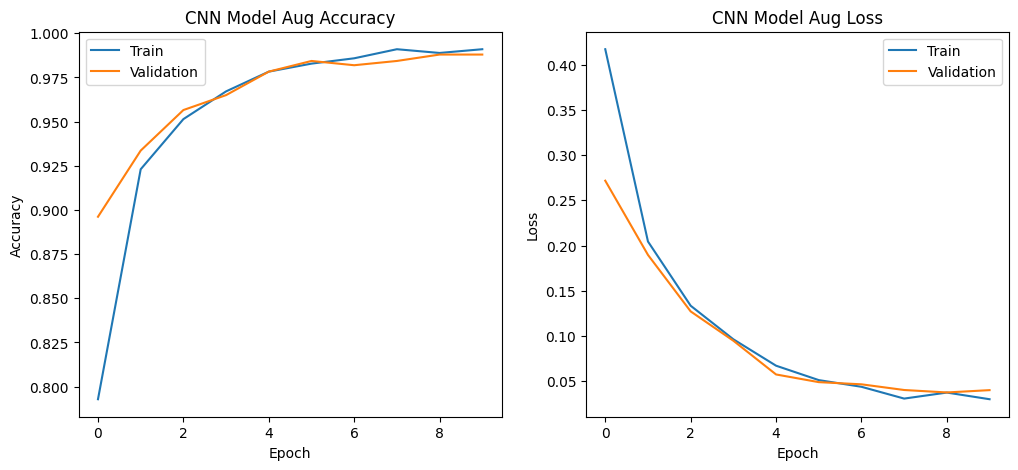

In [ ]:
# Example for Densenet_aug
metrics, y_true, y_pred = compute_metrics(densenet_model_aug, val_generator_dens)
print(metrics)  # {'accuracy': ..., 'precision': ..., 'recall': ..., 'f1_score': ...}
plot_confusion_matrix(y_true, y_pred)
plot_training_history(history_densenet_aug, 'CNN Model Aug')


### Performance

In [ ]:
import time

img, label = next(val_generator_dens)

sample = np.expand_dims(img[0], axis=0)

start = time.time()
densenet_model_aug.predict(sample)
end = time.time()

print("Response Time:", end - start)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Response Time: 12.687380075454712


In [ ]:
times = []

for i in range(50):
    sample = np.expand_dims(img[i % len(img)], axis=0)

    start = time.time()
    densenet_model_aug.predict(sample)
    end = time.time()

    times.append(end - start)

print("Average Latency:", sum(times)/len(times))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

In [ ]:
throughput = len(times) / sum(times)
print("Requests per second:", throughput)

Requests per second: 11.773832591491544


## Save Data

In [ ]:
# zip data
shutil.make_archive('old_data', 'zip', '/content/train')
shutil.make_archive('test_data', 'zip', '/content/test')
shutil.make_archive('future_data', 'zip', '/content/future_train')

'/content/future_data.zip'

In [ ]:
# Downloaded data
from google.colab import files

files.download('dataset.zip')
files.download('test_data.zip')
files.download('future_data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Save Model

In [ ]:
# Copy the models to google drive
!cp -r /content/models /content/drive/MyDrive/

In [ ]:
# Load the models for prediction
model1 = tf.keras.models.load_model('/content/densenet_best.keras')

## TEST

In [ ]:
# Check class indices
print(val_generator_dens.class_indices)

{'Brain Tumor': 0, 'Healthy': 1}


{'accuracy': 0.9927536231884058, 'precision': 0.9946524064171123, 'recall': 0.9893617021276596, 'f1_score': 0.992}


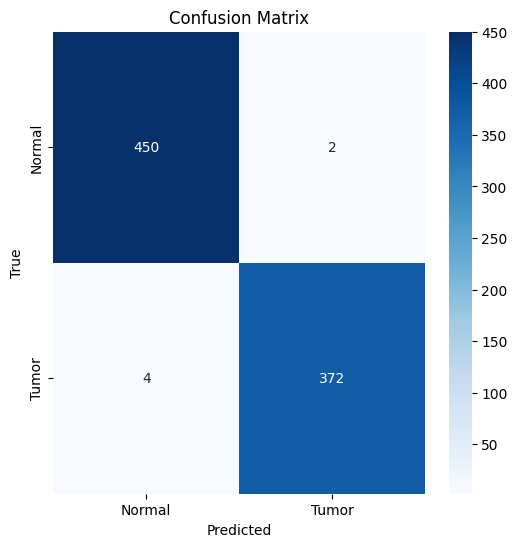

NameError: name 'history_densenet_aug' is not defined

In [ ]:
# Example for CNN
metrics, y_true, y_pred = compute_metrics(model1, val_generator_dens)
print(metrics)  # {'accuracy': ..., 'precision': ..., 'recall': ..., 'f1_score': ...}
plot_confusion_matrix(y_true, y_pred)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image
img_path = '/content/Not Cancer  (2).jpeg'
img = image.load_img(img_path, target_size=(224, 224))  # match model input size

# Convert to array
img_array = image.img_to_array(img)

# Expand dimensions (batch size = 1)
img_array = np.expand_dims(img_array, axis=0)

# Preprocess input if your model requires it (e.g., DenseNet)
from tensorflow.keras.applications.densenet import preprocess_input
img_array = preprocess_input(img_array)

# Make prediction
pred = model1.predict(img_array)

# If binary classification
pred_class = 1 if pred[0] > 0.5 else 0
print(f"Predicted class index: {pred_class}")

# Map back to class name
class_map = {v: k for k, v in val_generator_dens.class_indices.items()}
print(f"Predicted label: {class_map[pred_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Predicted class index: 0
Predicted label: Brain Tumor


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image
img_path = '/content/Cancer (6).jpg'
img = image.load_img(img_path, target_size=(224, 224))  # match model input size

# Convert to array
img_array = image.img_to_array(img)

# Expand dimensions (batch size = 1)
img_array = np.expand_dims(img_array, axis=0)

# Preprocess input if your model requires it (e.g., DenseNet)
from tensorflow.keras.applications.densenet import preprocess_input
img_array = preprocess_input(img_array)

# Make prediction
pred = model1.predict(img_array)

# If binary classification
pred_class = 1 if pred[0] > 0.5 else 0
print(f"Predicted class index: {pred_class}")

# Map back to class name
class_map = {v: k for k, v in val_generator_dens.class_indices.items()}
print(f"Predicted label: {class_map[pred_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted class index: 0
Predicted label: Brain Tumor
